In [2]:
import pandas as pd

In [3]:
import sqlite3

In [3]:
df = pd.read_csv('credit_card_transactions-ibm_v2.csv')

In [4]:
df.head() 

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


In [6]:
df['amount'] = df['Amount'].str.replace('$', '', regex=False).astype(float); df['txn_datetime'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-' + df['Day'].astype(str) + ' ' + df['Time']); df['card_id'] = df['User'].astype(str) + '_' + df['Card'].astype(str); df['is_fraud'] = (df['Is Fraud?'] == 'Yes').astype(int); df['merchant_city'] = df['Merchant City'].fillna('ONLINE'); df['merchant_state'] = df['Merchant State'].fillna('ONLINE')

In [8]:
conn = sqlite3.connect('fraud_analytics.db'); df[['card_id', 'User', 'amount', 'txn_datetime', 'Use Chip', 'Merchant Name', 'merchant_city', 'merchant_state', 'Zip', 'MCC', 'is_fraud']].to_sql('transactions', conn, if_exists='replace', index=False)
1
2
3


3

In [9]:
pd.read_sql("SELECT COUNT(*) AS total_transactions, SUM(is_fraud) AS fraud_transactions, ROUND(100.0 * SUM(is_fraud) / COUNT(*), 3) AS fraud_rate_pct FROM transactions", conn)

,total_transactions,fraud_transactions,fraud_rate_pct
0,24386900,29757,0.122


In [10]:
pd.read_sql("SELECT MCC, COUNT(*) AS total_transactions, SUM(is_fraud) AS fraud_transactions, ROUND(100.0 * SUM(is_fraud) / COUNT(*), 3) AS fraud_rate_pct FROM transactions GROUP BY MCC ORDER BY fraud_rate_pct DESC LIMIT 15", conn)

,MCC,total_transactions,fraud_transactions,fraud_rate_pct
0,4411,634,317,50.000
1,5733,496,127,25.605
2,5045,5013,470,9.376
3,3006,702,59,8.405
4,3144,632,53,8.386
5,3008,714,50,7.003
6,5732,12593,843,6.694
7,3007,666,41,6.156
8,3075,666,40,6.006
9,5094,9444,567,6.004


In [11]:
pd.read_sql("SELECT CAST(strftime('%H', txn_datetime) AS INTEGER) AS hour_of_day, COUNT(*) AS total_transactions, SUM(is_fraud) AS fraud_transactions, ROUND(100.0 * SUM(is_fraud) / COUNT(*), 3) AS fraud_rate_pct FROM transactions GROUP BY hour_of_day ORDER BY fraud_rate_pct DESC", conn)

,hour_of_day,total_transactions,fraud_transactions,fraud_rate_pct
0,10,1664499,3116,0.187
1,3,183370,342,0.187
2,4,203550,372,0.183
3,11,1736005,3146,0.181
4,13,1681236,2837,0.169
5,12,1739868,2933,0.169
6,5,321588,505,0.157
7,14,1632864,2408,0.147
8,15,1559102,2155,0.138
9,9,1598928,2178,0.136


In [12]:
pd.read_sql("SELECT CASE WHEN is_fraud = 1 THEN 'Fraud' ELSE 'Legitimate' END AS txn_type, COUNT(*) AS n_transactions, ROUND(AVG(amount), 2) AS avg_amount, ROUND(MIN(amount), 2) AS min_amount, ROUND(MAX(amount), 2) AS max_amount FROM transactions GROUP BY txn_type", conn)


,txn_type,n_transactions,avg_amount,min_amount,max_amount
0,Fraud,29757,108.59,-500.0,5694.44
1,Legitimate,24357143,43.55,-500.0,12390.50


In [13]:
pd.read_sql("SELECT card_id, COUNT(*) AS txn_count, SUM(is_fraud) AS fraud_count FROM transactions GROUP BY card_id HAVING COUNT(*) > 5000 ORDER BY fraud_count DESC LIMIT 15", conn)

,card_id,txn_count,fraud_count
0,320_2,6578,57
1,66_0,29361,48
2,1996_3,6610,48
3,1342_0,7528,47
4,861_0,15702,46
5,1101_1,14499,46
6,207_2,7961,45
7,1885_1,5165,43
8,1532_2,11651,43
9,1378_0,8046,43


In [14]:
pd.read_sql("SELECT `Merchant Name` AS merchant_id, MCC, COUNT(*) AS total_transactions, SUM(is_fraud) AS fraud_transactions, ROUND(100.0 * SUM(is_fraud) / COUNT(*), 3) AS fraud_rate_pct FROM transactions GROUP BY merchant_id, MCC HAVING COUNT(*) >= 100 ORDER BY fraud_rate_pct DESC LIMIT 15", conn)

,merchant_id,MCC,total_transactions,fraud_transactions,fraud_rate_pct
0,-7231389139399574921,5310,148,148,100.000
1,590183032319022035,5094,129,126,97.674
2,6051395022895754231,5310,407,380,93.366
3,2919745757515313025,5932,101,94,93.069
4,-2985456613733500756,7011,184,114,61.957
5,-2072851135875924699,4411,131,76,58.015
6,-3943656582743129537,5712,126,73,57.937
7,5507353000713503121,4121,311,160,51.447
8,-7421991366943579652,4411,119,61,51.261
9,-7576589894704936102,4411,130,66,50.769


In [15]:
pd.read_sql("SELECT card_id, txn_datetime, amount, is_fraud, (SELECT COUNT(*) FROM transactions t2 WHERE t2.card_id = t.card_id AND t2.txn_datetime <= t.txn_datetime AND t2.txn_datetime > datetime(t.txn_datetime, '-24 hours')) AS txn_count_trailing_24hr FROM transactions t WHERE card_id = '320_2' ORDER BY txn_datetime LIMIT 30", conn)

,card_id,txn_datetime,amount,is_fraud,txn_count_trailing_24hr
0,320_2,2004-02-21 05:39:00,681.20,0,1
1,320_2,2004-05-11 18:24:00,716.77,0,1
2,320_2,2004-07-01 09:00:00,120.00,0,1
3,320_2,2004-07-01 10:34:00,11.11,0,2
4,320_2,2004-07-01 20:20:00,90.06,0,3
5,320_2,2004-07-02 09:01:00,100.00,0,3
6,320_2,2004-07-03 09:11:00,120.00,0,1
7,320_2,2004-07-03 10:51:00,8.79,0,2
8,320_2,2004-07-03 11:01:00,67.54,0,3
9,320_2,2004-07-04 10:09:00,10.48,0,3


In [16]:
pd.read_sql("SELECT card_id, txn_datetime, amount, is_fraud, (SELECT COUNT(*) FROM transactions t2 WHERE t2.card_id = t.card_id AND t2.txn_datetime <= t.txn_datetime AND t2.txn_datetime > datetime(t.txn_datetime, '-24 hours')) AS txn_count_trailing_24hr FROM transactions t WHERE card_id = '320_2' AND is_fraud = 1 ORDER BY txn_datetime LIMIT 20", conn)

,card_id,txn_datetime,amount,is_fraud,txn_count_trailing_24hr
0,320_2,2005-08-22 10:47:00,213.06,1,1
1,320_2,2005-08-22 12:42:00,51.19,1,2
2,320_2,2005-08-22 15:30:00,72.49,1,3
3,320_2,2005-08-22 17:45:00,53.80,1,4
4,320_2,2005-08-29 16:09:00,129.72,1,3
5,320_2,2005-08-29 17:26:00,15.58,1,4
6,320_2,2005-08-31 10:54:00,56.02,1,4
7,320_2,2005-08-31 17:45:00,96.49,1,4
8,320_2,2005-09-05 15:34:00,35.91,1,2
9,320_2,2005-09-05 15:58:00,0.05,1,3


In [17]:
pd.read_sql("WITH ordered_txns AS (SELECT card_id, amount, merchant_state, txn_datetime, LAG(merchant_state) OVER (PARTITION BY card_id ORDER BY txn_datetime) AS prev_state, LAG(txn_datetime) OVER (PARTITION BY card_id ORDER BY txn_datetime) AS prev_time FROM transactions WHERE merchant_state != 'ONLINE') SELECT card_id, prev_state, merchant_state, prev_time, txn_datetime, ROUND((julianday(txn_datetime) - julianday(prev_time)) * 24, 2) AS hours_between FROM ordered_txns WHERE merchant_state != prev_state AND (julianday(txn_datetime) - julianday(prev_time)) * 24 < 2 ORDER BY hours_between ASC LIMIT 20", conn)

,card_id,prev_state,merchant_state,prev_time,txn_datetime,hours_between
0,1002_2,Italy,TN,2018-08-17 17:02:00,2018-08-17 17:02:00,0.0
1,1006_0,NC,NY,2016-10-02 05:58:00,2016-10-02 05:58:00,0.0
2,1006_0,NV,CA,2018-11-24 11:37:00,2018-11-24 11:37:00,0.0
3,1006_1,NJ,NY,2003-08-18 13:37:00,2003-08-18 13:37:00,0.0
4,1006_1,IL,NY,2003-08-28 17:50:00,2003-08-28 17:50:00,0.0
5,1006_1,WA,NY,2004-01-23 20:08:00,2004-01-23 20:08:00,0.0
6,1006_1,AR,NY,2005-07-03 19:54:00,2005-07-03 19:54:00,0.0
7,1008_0,AK,NC,2015-11-12 15:44:00,2015-11-12 15:44:00,0.0
8,1009_1,OH,MN,2018-06-19 12:23:00,2018-06-19 12:23:00,0.0
9,1013_2,FL,AR,2003-10-31 12:29:00,2003-10-31 12:29:00,0.0


In [19]:
 conn.execute("CREATE INDEX IF NOT EXISTS idx_card ON transactions(card_id)"); conn.execute("CREATE INDEX IF NOT EXISTS idx_merchant ON transactions(`Merchant Name`)"); conn.commit()

In [20]:
pd.read_sql("WITH card_avg AS (SELECT card_id, AVG(amount) AS card_avg_amount FROM transactions WHERE amount > 0 GROUP BY card_id), merchant_risk AS (SELECT `Merchant Name` AS merchant_id, 1.0*SUM(is_fraud)/COUNT(*) AS merchant_fraud_rate FROM transactions GROUP BY merchant_id HAVING COUNT(*) >= 100) SELECT t.card_id, t.txn_datetime, t.amount, t.is_fraud, ROUND(ABS(t.amount - ca.card_avg_amount),2) AS amount_deviation, ROUND(COALESCE(mr.merchant_fraud_rate,0),4) AS merchant_fraud_rate, ROUND(0.5*(ABS(t.amount-ca.card_avg_amount)/NULLIF(ca.card_avg_amount,0)) + 0.5*COALESCE(mr.merchant_fraud_rate,0)*10, 4) AS composite_risk_score FROM transactions t JOIN card_avg ca ON ca.card_id = t.card_id LEFT JOIN merchant_risk mr ON mr.merchant_id = t.`Merchant Name` ORDER BY composite_risk_score DESC LIMIT 20", conn)

,card_id,txn_datetime,amount,is_fraud,amount_deviation,merchant_fraud_rate,composite_risk_score
0,764_1,2019-01-04 13:10:00,1135.92,1,1130.10,0.0100,97.1851
1,1395_0,2010-12-13 03:44:00,4133.28,1,4103.09,0.5077,70.4939
2,1975_1,2008-11-14 11:29:00,927.31,1,920.23,0.0000,64.9433
3,1980_1,2010-12-19 12:29:00,3303.68,1,3275.73,0.4091,60.6451
4,693_3,2004-01-17 06:57:00,12390.50,0,12283.10,0.5126,59.7480
5,187_0,2010-07-26 09:14:00,1422.41,1,1410.02,0.4091,58.9588
6,283_0,2017-09-14 19:26:00,4351.56,0,4310.87,0.4918,55.4294
7,1379_3,2010-10-22 03:42:00,2692.02,1,2666.09,0.4918,53.8679
8,177_1,2002-07-23 11:17:00,3111.35,0,3081.28,0.4091,53.2807
9,230_0,2010-08-25 21:02:00,4199.33,0,4158.71,0.4091,53.2420


In [21]:
pd.read_sql("WITH card_score AS (SELECT card_id, COUNT(*) AS txn_count, SUM(is_fraud) AS fraud_count, 1.0*SUM(is_fraud)/COUNT(*) AS fraud_rate FROM transactions GROUP BY card_id), deciled AS (SELECT *, NTILE(10) OVER (ORDER BY fraud_rate DESC) AS risk_decile FROM card_score) SELECT risk_decile, COUNT(*) AS n_cards, SUM(fraud_count) AS total_fraud_in_decile, ROUND(AVG(fraud_rate),5) AS avg_fraud_rate FROM deciled GROUP BY risk_decile ORDER BY risk_decile", conn)

,risk_decile,n_cards,total_fraud_in_decile,avg_fraud_rate
0,1,614,10568,0.01146
1,2,614,8223,0.00302
2,3,614,6281,0.00161
3,4,614,3843,0.00077
4,5,614,842,0.00013
5,6,614,0,0.00000
6,7,614,0,0.00000
7,8,614,0,0.00000
8,9,614,0,0.00000
9,10,613,0,0.00000


In [22]:
pd.read_sql("WITH ordered AS (SELECT card_id, amount, txn_datetime, is_fraud, LEAD(amount) OVER (PARTITION BY card_id ORDER BY txn_datetime) AS next_amount, LEAD(txn_datetime) OVER (PARTITION BY card_id ORDER BY txn_datetime) AS next_time FROM transactions WHERE amount > 0) SELECT card_id, amount AS test_charge_amount, txn_datetime AS test_charge_time, next_amount AS followup_amount, next_time AS followup_time, ROUND((julianday(next_time)-julianday(txn_datetime))*24*60,1) AS minutes_between FROM ordered WHERE amount <= 2.00 AND next_amount >= 100.00 AND (julianday(next_time)-julianday(txn_datetime))*24 <= 1 ORDER BY minutes_between ASC LIMIT 20", conn)

,card_id,test_charge_amount,test_charge_time,followup_amount,followup_time,minutes_between
0,1005_0,0.78,2017-11-01 14:44:00,129.33,2017-11-01 14:44:00,0.0
1,1036_7,1.83,2005-02-21 13:03:00,519.79,2005-02-21 13:03:00,0.0
2,1044_0,1.17,2018-07-02 06:42:00,129.17,2018-07-02 06:42:00,0.0
3,1063_4,0.31,2019-06-25 07:04:00,521.01,2019-06-25 07:04:00,0.0
4,1078_1,0.53,2018-07-17 11:37:00,114.65,2018-07-17 11:37:00,0.0
5,107_1,1.53,2015-12-21 11:11:00,248.34,2015-12-21 11:11:00,0.0
6,1080_0,1.48,2011-03-30 07:13:00,141.01,2011-03-30 07:13:00,0.0
7,1111_2,1.41,1999-08-03 20:12:00,172.52,1999-08-03 20:12:00,0.0
8,112_0,2.00,2007-05-19 02:21:00,151.00,2007-05-19 02:21:00,0.0
9,1131_0,0.13,2014-02-04 10:44:00,123.14,2014-02-04 10:44:00,0.0


In [4]:
conn = sqlite3.connect('../Data/fraud_analytics.db')

In [3]:
conn.execute("CREATE INDEX IF NOT EXISTS idx_merchant_time ON transactions(`Merchant Name`, txn_datetime)"); conn.commit()

In [4]:
pd.read_sql("WITH risky_merchants AS (SELECT `Merchant Name` AS merchant_id FROM transactions GROUP BY merchant_id HAVING COUNT(*) >= 100 AND 1.0*SUM(is_fraud)/COUNT(*) >= 0.1), fraud_txns AS (SELECT card_id, `Merchant Name` AS merchant_id, txn_datetime FROM transactions WHERE is_fraud = 1 AND `Merchant Name` IN (SELECT merchant_id FROM risky_merchants)) SELECT f.merchant_id, COUNT(DISTINCT t.card_id) AS distinct_cards_involved FROM fraud_txns f JOIN transactions t ON t.`Merchant Name` = f.merchant_id AND t.txn_datetime BETWEEN f.txn_datetime AND datetime(f.txn_datetime, '+1 hour') AND t.card_id != f.card_id GROUP BY f.merchant_id HAVING COUNT(DISTINCT t.card_id) >= 3 ORDER BY distinct_cards_involved DESC LIMIT 20", conn)

,merchant_id,distinct_cards_involved
0,6051395022895754231,43
1,-1642303950890406395,16
2,-7231389139399574921,10
3,4573875080712571902,10
4,6998358937427405121,8
5,-2985456613733500756,6
6,5507353000713503121,6
7,590183032319022035,3


In [5]:
conn.execute("CREATE INDEX IF NOT EXISTS idx_card_amount ON transactions(card_id, amount)"); conn.commit()

In [6]:
pd.read_sql("WITH ranked AS (SELECT card_id, amount, is_fraud, txn_datetime, PERCENT_RANK() OVER (PARTITION BY card_id ORDER BY amount) AS pct_rank FROM transactions WHERE amount > 0), card_p95 AS (SELECT card_id, MIN(amount) AS p95_amount FROM ranked WHERE pct_rank >= 0.95 GROUP BY card_id) SELECT t.card_id, t.txn_datetime, t.amount, t.is_fraud, cp.p95_amount FROM transactions t JOIN card_p95 cp ON cp.card_id = t.card_id WHERE t.amount > cp.p95_amount ORDER BY t.is_fraud DESC, t.amount DESC LIMIT 20", conn)

,card_id,txn_datetime,amount,is_fraud,p95_amount
0,624_1,2010-09-05 08:14:00,5694.44,1,155.47
1,1547_0,2010-03-26 07:00:00,4978.45,1,196.69
2,1395_0,2010-12-13 03:44:00,4133.28,1,121.93
3,683_4,2010-04-11 03:21:00,3854.44,1,141.89
4,412_0,2010-11-22 05:39:00,3812.03,1,160.38
5,1_4,2010-03-22 08:27:00,3750.60,1,91.92
6,625_0,2010-11-14 11:51:00,3416.64,1,208.20
7,1980_1,2010-12-19 12:29:00,3303.68,1,94.70
8,940_3,2010-10-03 12:49:00,3084.57,1,144.96
9,1594_1,2015-08-10 11:18:00,2930.44,1,91.95


In [7]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


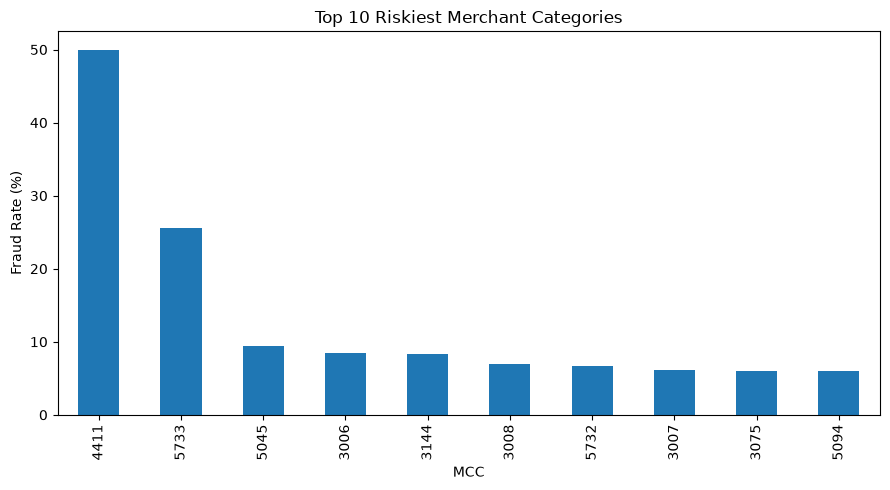

In [9]:
fraud_by_mcc = pd.read_sql("SELECT MCC, ROUND(100.0*SUM(is_fraud)/COUNT(*),2) AS fraud_rate_pct FROM transactions GROUP BY MCC HAVING COUNT(*) >= 100 ORDER BY fraud_rate_pct DESC LIMIT 10", conn); fraud_by_mcc.plot(kind='bar', x='MCC', y='fraud_rate_pct', legend=False, title='Top 10 Riskiest Merchant Categories', figsize=(9,5)); plt.ylabel('Fraud Rate (%)'); plt.tight_layout(); plt.show()

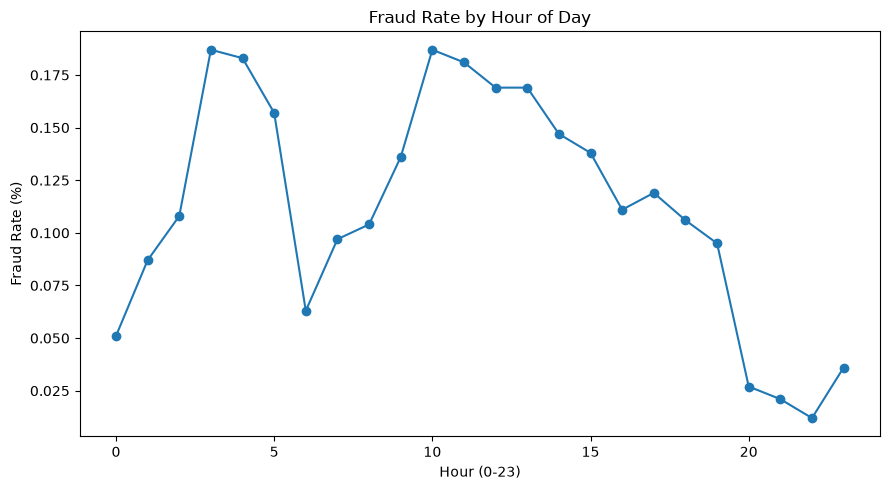

In [10]:
fraud_by_hour = pd.read_sql("SELECT CAST(strftime('%H', txn_datetime) AS INTEGER) AS hour, ROUND(100.0*SUM(is_fraud)/COUNT(*),3) AS fraud_rate_pct FROM transactions GROUP BY hour ORDER BY hour", conn); fraud_by_hour.plot(kind='line', x='hour', y='fraud_rate_pct', marker='o', legend=False, title='Fraud Rate by Hour of Day', figsize=(9,5)); plt.ylabel('Fraud Rate (%)'); plt.xlabel('Hour (0-23)'); plt.tight_layout(); plt.show()

In [13]:
model_df = pd.read_sql("SELECT card_id, amount, is_fraud, txn_datetime FROM transactions WHERE ABS(RANDOM()) % 100 < 1", conn)

In [14]:
model_df.shape 

(244308, 4)

In [15]:
model_df = model_df.sort_values(['card_id', 'txn_datetime']); card_avg = model_df.groupby('card_id')['amount'].transform('mean'); model_df['amount_deviation'] = (model_df['amount'] - card_avg).abs()

In [16]:
model_df[['card_id','amount','amount_deviation','is_fraud']].head(10)

,card_id,amount,amount_deviation,is_fraud
0,0_0,211.00,134.219333,0
1,0_0,69.12,7.660667,0
2,0_0,50.12,26.660667,0
3,0_0,44.00,32.780667,0
4,0_0,58.67,18.110667,0
5,0_0,120.79,44.009333,0
6,0_0,118.41,41.629333,0
7,0_0,75.38,1.400667,0
8,0_0,67.11,9.670667,0
9,0_0,6.06,70.720667,0


In [17]:
model_df['hour'] = pd.to_datetime(model_df['txn_datetime']).dt.hour

In [19]:
model_df['card_txn_count'] = model_df.groupby('card_id')['card_id'].transform('count')

In [20]:
model_df[['card_id','amount','amount_deviation','hour','card_txn_count','is_fraud']].sample(10)

,card_id,amount,amount_deviation,hour,card_txn_count,is_fraud
177304,1429_2,3.54,32.205556,7,54,0
160651,1303_1,7.79,33.018543,6,151,0
113073,938_4,14.43,125.405000,5,4,0
91940,788_1,35.27,7.208169,7,71,0
124995,1024_1,23.75,18.579615,15,26,0
5841,47_0,17.11,7.619828,11,116,0
90414,777_5,50.58,13.752024,11,168,0
165479,1338_1,47.84,2.555217,6,138,0
194683,1575_3,5.39,48.439081,10,185,0
43060,359_1,-99.00,146.939531,7,64,0


In [21]:
from sklearn.model_selection import train_test_split

In [23]:
features = ['amount', 'amount_deviation', 'hour', 'card_txn_count']; X = model_df[features]; y = model_df['is_fraud']; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [24]:
print('Training rows:', len(X_train), '| Testing rows:', len(X_test), '| Fraud in training:', y_train.sum(), '| Fraud in testing:', y_test.sum())

Training rows: 183231 | Testing rows: 61077 | Fraud in training: 252 | Fraud in testing: 84


In [25]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression(class_weight='balanced', max_iter=1000); model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [29]:
from sklearn.metrics import classification_report, roc_auc_score

In [30]:
y_pred = model.predict(X_test); y_proba = model.predict_proba(X_test)[:, 1]

In [31]:
print(classification_report(y_test, y_pred)); print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

           0       1.00      0.72      0.84     60993
           1       0.00      0.56      0.01        84

    accuracy                           0.72     61077
   macro avg       0.50      0.64      0.42     61077
weighted avg       1.00      0.72      0.84     61077

ROC-AUC: 0.6886


In [32]:
model_df = pd.read_sql("SELECT card_id, `Merchant Name` AS merchant_id, amount, is_fraud, txn_datetime FROM transactions WHERE ABS(RANDOM()) % 100 < 1", conn)

In [33]:
model_df = model_df.sort_values(['card_id','txn_datetime']); card_avg = model_df.groupby('card_id')['amount'].transform('mean'); model_df['amount_deviation'] = (model_df['amount'] - card_avg).abs(); model_df['hour'] = pd.to_datetime(model_df['txn_datetime']).dt.hour; model_df['card_txn_count'] = model_df.groupby('card_id')['card_id'].transform('count')

In [34]:
model_df.shape

(243614, 8)

In [38]:
merchant_risk = pd.read_sql("SELECT `Merchant Name` AS merchant_id, 1.0*SUM(is_fraud)/COUNT(*) AS merchant_fraud_rate FROM transactions GROUP BY merchant_id HAVING COUNT(*) >= 100", conn)

KeyboardInterrupt: 

In [36]:
card_list = tuple(model_df['card_id'].unique())

In [37]:
card_p95 = pd.read_sql(f"WITH ranked AS (SELECT card_id, amount, PERCENT_RANK() OVER (PARTITION BY card_id ORDER BY amount) AS pct_rank FROM transactions WHERE amount > 0 AND card_id IN {card_list}) SELECT card_id, MIN(amount) AS p95_amount FROM ranked WHERE pct_rank >= 0.95 GROUP BY card_id", conn)

In [39]:
merchant_list = tuple(model_df['merchant_id'].unique())

In [41]:
merchant_risk = pd.read_sql(f"SELECT `Merchant Name` AS merchant_id, 1.0*SUM(is_fraud)/COUNT(*) AS merchant_fraud_rate FROM transactions WHERE `Merchant Name` IN {merchant_list} GROUP BY merchant_id HAVING COUNT(*) >= 100", conn)

DatabaseError: Execution failed on sql 'SELECT `Merchant Name` AS merchant_id, 1.0*SUM(is_fraud)/COUNT(*) AS merchant_fraud_rate FROM transactions WHERE `Merchant Name` IN (np.int64(-4500542936415012428), np.int64(7834055923142137930), np.int64(-5475680618560174533), np.int64(4060646732831064559), np.int64(4055257078481058705), np.int64(-6733168469687845480), np.int64(-6406662083475903219), np.int64(-34551508091458520), np.int64(5817218446178736267), np.int64(1913477460590765860), np.int64(838425044734233142), np.int64(-727612092139916043), np.int64(2027553650310142703), np.int64(-7807051024009846392), np.int64(-1548743109648102646), np.int64(-245178307025547046), np.int64(-3345936507911876459), np.int64(8245762104511734345), np.int64(-1288082279022882052), np.int64(-5023497618971072366), np.int64(3527213246127876953), np.int64(97032797689821735), np.int64(8080934608468946743), np.int64(-2241979537006931381), np.int64(-8566951830324093739), np.int64(1799189980464955940), np.int64(10467

In [42]:
merchant_list = tuple(int(x) for x in model_df['merchant_id'].unique())

In [43]:
merchant_risk = pd.read_sql(f"SELECT `Merchant Name` AS merchant_id, 1.0*SUM(is_fraud)/COUNT(*) AS merchant_fraud_rate FROM transactions WHERE `Merchant Name` IN {merchant_list} GROUP BY merchant_id HAVING COUNT(*) >= 100", conn)

In [44]:
merchant_risk.shape

(10124, 2)

In [45]:
model_df = model_df.merge(merchant_risk, on='merchant_id', how='left'); model_df['merchant_fraud_rate'] = model_df['merchant_fraud_rate'].fillna(0)

In [46]:
model_df = model_df.merge(card_p95, on='card_id', how='left'); model_df['above_p95'] = (model_df['amount'] > model_df['p95_amount']).astype(int); model_df['above_p95'] = model_df['above_p95'].fillna(0)

In [47]:
model_df.shape

(243614, 11)

In [48]:
features = ['amount', 'amount_deviation', 'hour', 'card_txn_count', 'merchant_fraud_rate', 'above_p95']; X = model_df[features]; y = model_df['is_fraud']; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [49]:
model2 = LogisticRegression(class_weight='balanced', max_iter=1000); model2.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [50]:
y_pred2 = model2.predict(X_test); y_proba2 = model2.predict_proba(X_test)[:, 1]; print(classification_report(y_test, y_pred2)); print('ROC-AUC:', round(roc_auc_score(y_test, y_proba2), 4))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     60832
           1       0.01      0.72      0.02        72

    accuracy                           0.89     60904
   macro avg       0.50      0.81      0.48     60904
weighted avg       1.00      0.89      0.94     60904

ROC-AUC: 0.8623
